# Coastal Frontier — Hypothesis Testing

**Three pre-declared measures of southward spread.**

H1 states that jihadist violence has spread southward from the Sahel core into the
littoral states at an accelerating rate since 2020. We test this with three
*independent* operationalizations:

| Measure | Definition | H1 supported if |
|---|---|---|
| **M1: Southern frontier** | 5th-percentile latitude of events per quarter | M1 **falls** over time |
| **M2: Littoral share** | Share of events in Togo / Benin / Côte d'Ivoire / Ghana per quarter | M2 **rises** over time |
| **M3: Center of gravity** | Mean latitude of events per quarter | M3 **falls** over time |

The directions were declared **before** the data was loaded. If all three agree, the
finding is robust. If they disagree, the disagreement is itself the finding.

In [1]:
# --- Imports and setup ---
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.coastal_frontier.config import DATA_INTERIM

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.max_columns", None)

SAHEL_CORE = {"Mali", "Burkina Faso", "Niger"}
LITTORAL = {"Togo", "Benin", "Ivory Coast", "Ghana"}

print("Sahel core:", SAHEL_CORE)
print("Littoral:", LITTORAL)

Sahel core: {'Niger', 'Mali', 'Burkina Faso'}
Littoral: {'Togo', 'Ghana', 'Benin', 'Ivory Coast'}


In [2]:
# --- Load + add quarter and region tags ---
df = pd.read_parquet(DATA_INTERIM / "ucdp_events_filtered.parquet")
df["date_start"] = pd.to_datetime(df["date_start"])
df["quarter"] = df["date_start"].dt.to_period("Q")
df["region_cat"] = df["country"].apply(
    lambda c: "Sahel" if c in SAHEL_CORE else "Littoral" if c in LITTORAL else "Other"
)

unmapped = df[df["region_cat"] == "Other"]["country"].unique()
assert len(unmapped) == 0, f"Unmapped countries: {unmapped}"

print(f"Loaded {len(df):,} events across {df['quarter'].nunique()} quarters")
print(f"Quarter range: {df['quarter'].min()} to {df['quarter'].max()}")
print(f"Sahel events: {(df['region_cat'] == 'Sahel').sum():,}")
print(f"Littoral events: {(df['region_cat'] == 'Littoral').sum():,}")

Loaded 3,096 events across 21 quarters
Quarter range: 2020Q1 to 2026Q2
Sahel events: 2,980
Littoral events: 116


## Measure 1 — The southern frontier

The 5th-percentile latitude of events per quarter. We use a percentile rather than
the absolute minimum to avoid being swayed by single outliers — one stray event in
coastal Ghana shouldn't shift the "frontier" by 5 degrees. The 5th percentile
captures the *leading edge* while staying statistically stable.

**H1 prediction:** M1 falls over time.

In [3]:
m1 = (
    df.groupby("quarter")["latitude"]
    .quantile(0.05)
    .rename("frontier_lat_p05")
    .reset_index()
)
m1["quarter_dt"] = m1["quarter"].dt.to_timestamp()

x = (m1["quarter_dt"] - m1["quarter_dt"].min()).dt.days.values
y = m1["frontier_lat_p05"].values
slope_m1, intercept_m1 = np.polyfit(x, y, 1)
m1_deg_per_year = slope_m1 * 365.25
print(f"M1 trend: {m1_deg_per_year:+.3f}° latitude per year")
print(f"(negative = frontier moving south, positive = moving north)")
m1.head()

M1 trend: -0.215° latitude per year
(negative = frontier moving south, positive = moving north)


,quarter,frontier_lat_p05,quarter_dt
0,2020Q1,13.102853,2020-01-01
1,2020Q2,12.433332,2020-04-01
2,2020Q3,12.074998,2020-07-01
3,2020Q4,13.151795,2020-10-01
4,2021Q1,12.050000,2021-01-01


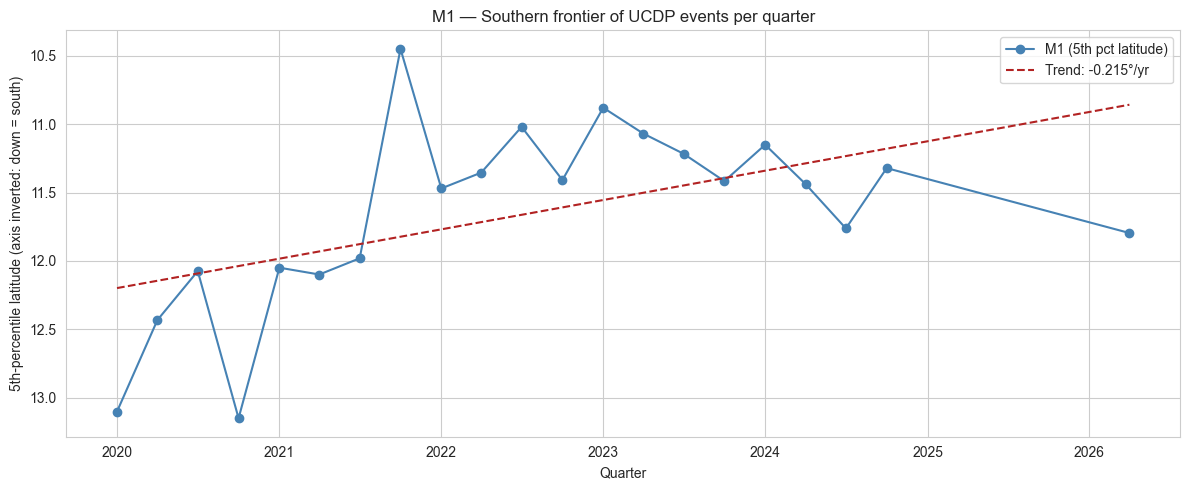

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(m1["quarter_dt"], m1["frontier_lat_p05"], marker="o", color="steelblue", label="M1 (5th pct latitude)")
ax.plot(m1["quarter_dt"], intercept_m1 + slope_m1 * x, "--", color="firebrick", label=f"Trend: {m1_deg_per_year:+.3f}°/yr")
ax.invert_yaxis()
ax.set_xlabel("Quarter")
ax.set_ylabel("5th-percentile latitude (axis inverted: down = south)")
ax.set_title("M1 — Southern frontier of UCDP events per quarter")
ax.legend()
plt.tight_layout()
plt.show()

## Measure 2 — Littoral share

The fraction of regional events occurring in the four littoral countries.
Even if total event volume stays flat, if violence is *moving* south the
share appearing in southern countries should rise.

**H1 prediction:** M2 rises over time.

In [5]:
m2 = (
    df.assign(is_littoral=df["region_cat"] == "Littoral")
    .groupby("quarter")
    .agg(n_total=("id", "size"), n_littoral=("is_littoral", "sum"))
    .reset_index()
)
m2["littoral_share"] = m2["n_littoral"] / m2["n_total"]
m2["quarter_dt"] = m2["quarter"].dt.to_timestamp()

x = (m2["quarter_dt"] - m2["quarter_dt"].min()).dt.days.values
y = m2["littoral_share"].values
slope_m2, intercept_m2 = np.polyfit(x, y, 1)
m2_pp_per_year = slope_m2 * 365.25 * 100
print(f"M2 trend: {m2_pp_per_year:+.2f} percentage points per year")
print(f"(positive = littoral share growing, supports H1)")
m2.tail()

M2 trend: +0.79 percentage points per year
(positive = littoral share growing, supports H1)


,quarter,n_total,n_littoral,littoral_share,quarter_dt
16,2024Q1,193,14,0.072539,2024-01-01
17,2024Q2,229,13,0.056769,2024-04-01
18,2024Q3,137,6,0.043796,2024-07-01
19,2024Q4,186,11,0.059140,2024-10-01
20,2026Q2,59,0,0.000000,2026-04-01


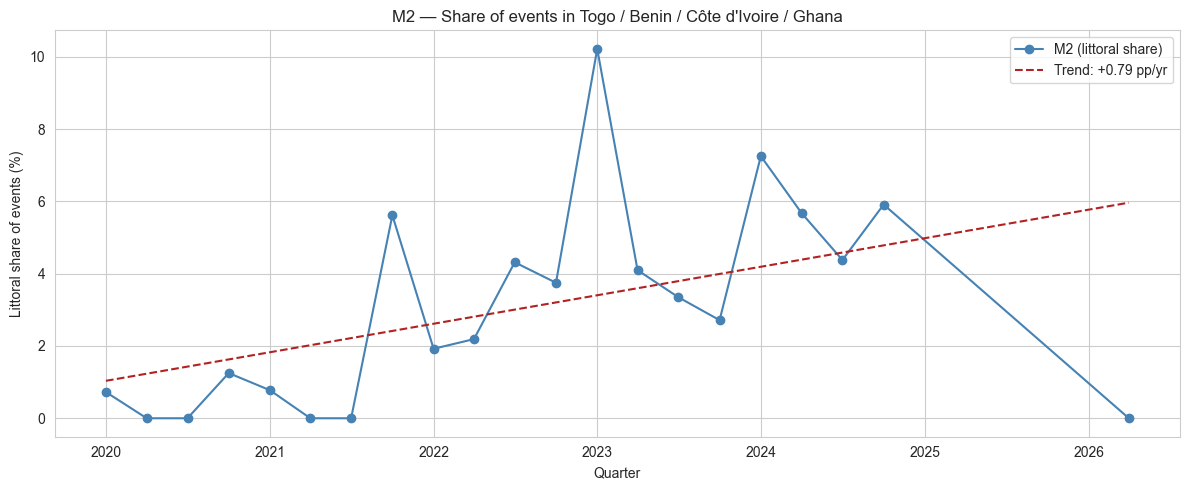

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(m2["quarter_dt"], m2["littoral_share"] * 100, marker="o", color="steelblue", label="M2 (littoral share)")
ax.plot(m2["quarter_dt"], (intercept_m2 + slope_m2 * x) * 100, "--", color="firebrick", label=f"Trend: {m2_pp_per_year:+.2f} pp/yr")
ax.set_xlabel("Quarter")
ax.set_ylabel("Littoral share of events (%)")
ax.set_title("M2 — Share of events in Togo / Benin / Côte d'Ivoire / Ghana")
ax.legend()
plt.tight_layout()
plt.show()

## Measure 3 — Center of gravity

The mean latitude of all events per quarter. M1 tracks the leading edge; M3
tracks the bulk. If new activity is appearing in the south while old activity
continues in the Sahel, the mean is pulled south gradually.

**H1 prediction:** M3 falls over time.

In [7]:
m3 = (
    df.groupby("quarter")["latitude"]
    .mean()
    .rename("mean_lat")
    .reset_index()
)
m3["quarter_dt"] = m3["quarter"].dt.to_timestamp()

x = (m3["quarter_dt"] - m3["quarter_dt"].min()).dt.days.values
y = m3["mean_lat"].values
slope_m3, intercept_m3 = np.polyfit(x, y, 1)
m3_deg_per_year = slope_m3 * 365.25
print(f"M3 trend: {m3_deg_per_year:+.3f}° latitude per year")
print(f"(negative = center of gravity moving south, supports H1)")
m3.head()

M3 trend: -0.032° latitude per year
(negative = center of gravity moving south, supports H1)


,quarter,mean_lat,quarter_dt
0,2020Q1,14.213009,2020-01-01
1,2020Q2,14.356689,2020-04-01
2,2020Q3,14.311288,2020-07-01
3,2020Q4,14.493677,2020-10-01
4,2021Q1,14.375864,2021-01-01


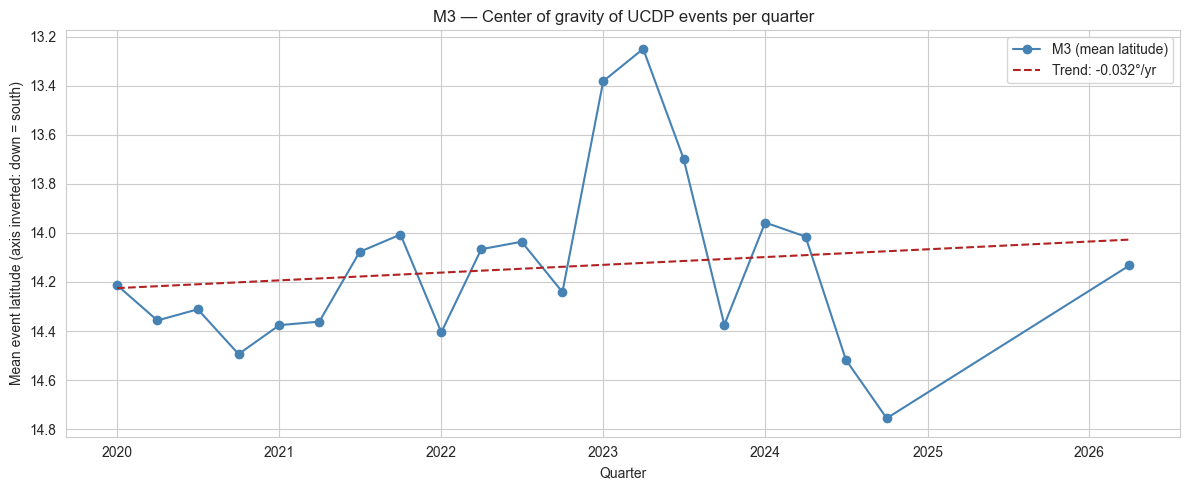

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(m3["quarter_dt"], m3["mean_lat"], marker="o", color="steelblue", label="M3 (mean latitude)")
ax.plot(m3["quarter_dt"], intercept_m3 + slope_m3 * x, "--", color="firebrick", label=f"Trend: {m3_deg_per_year:+.3f}°/yr")
ax.invert_yaxis()
ax.set_xlabel("Quarter")
ax.set_ylabel("Mean event latitude (axis inverted: down = south)")
ax.set_title("M3 — Center of gravity of UCDP events per quarter")
ax.legend()
plt.tight_layout()
plt.show()

## Synthesis — do the three measures agree?

Three measures, three pre-declared directions. We z-score each so they share a
y-axis, and flip M1 and M3 so that "positive = supports H1" for all three.
Lines living above zero in recent quarters means H1 is supported.

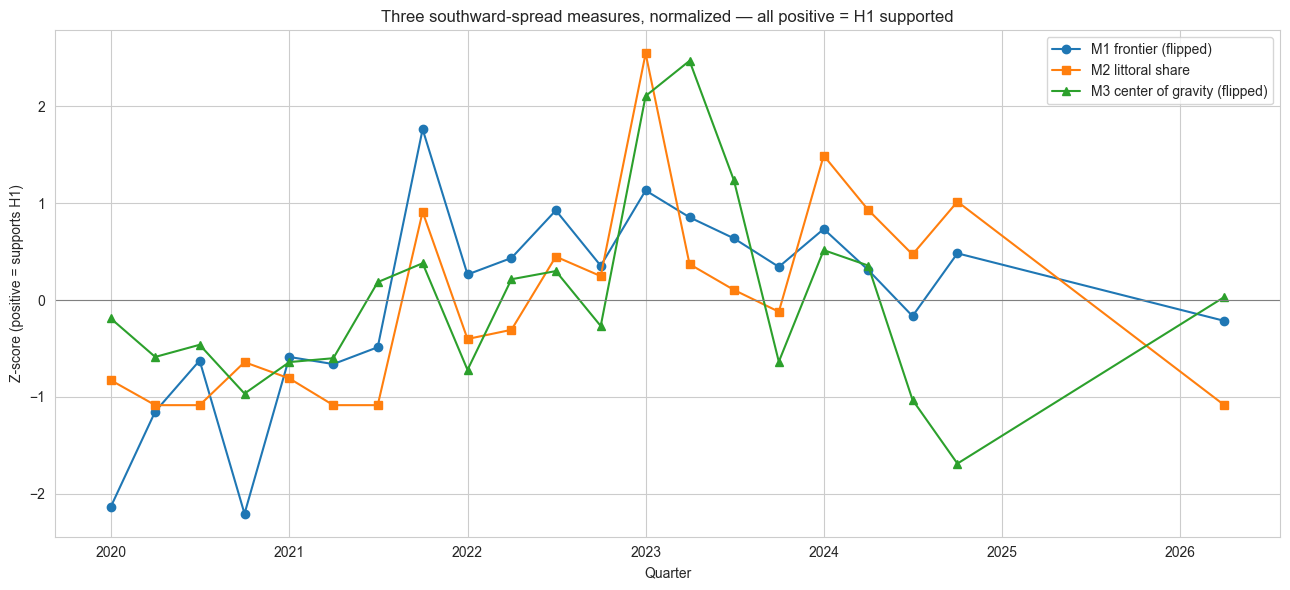


Pairwise correlations of H1-supporting versions:
                M1_supports_H1  M2_supports_H1  M3_supports_H1
M1_supports_H1            1.00            0.70            0.49
M2_supports_H1            0.70            1.00            0.44
M3_supports_H1            0.49            0.44            1.00


In [9]:
combined = (
    m1[["quarter_dt", "frontier_lat_p05"]]
    .merge(m2[["quarter_dt", "littoral_share"]], on="quarter_dt")
    .merge(m3[["quarter_dt", "mean_lat"]], on="quarter_dt")
)

for col in ["frontier_lat_p05", "littoral_share", "mean_lat"]:
    combined[col + "_z"] = (combined[col] - combined[col].mean()) / combined[col].std()

combined["M1_supports_H1"] = -combined["frontier_lat_p05_z"]
combined["M2_supports_H1"] = combined["littoral_share_z"]
combined["M3_supports_H1"] = -combined["mean_lat_z"]

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(combined["quarter_dt"], combined["M1_supports_H1"], marker="o", label="M1 frontier (flipped)")
ax.plot(combined["quarter_dt"], combined["M2_supports_H1"], marker="s", label="M2 littoral share")
ax.plot(combined["quarter_dt"], combined["M3_supports_H1"], marker="^", label="M3 center of gravity (flipped)")
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_xlabel("Quarter")
ax.set_ylabel("Z-score (positive = supports H1)")
ax.set_title("Three southward-spread measures, normalized — all positive = H1 supported")
ax.legend()
plt.tight_layout()
plt.show()

print("\nPairwise correlations of H1-supporting versions:")
print(combined[["M1_supports_H1", "M2_supports_H1", "M3_supports_H1"]].corr().round(2))


## Findings

*Filled in after running cells above. The synthesis chart and correlation matrix
are the headline results.*

**Verdict on H1:**
- (one direct sentence — supported, partially supported, or rejected — with the numbers)

**Inflection points to investigate:**
- (when do the lines bend? does the timing line up with the context timeline —
  coups, withdrawals, Wagner deployment?)

**Methodological caveats activated:**
- (which limitations from the README would temper this finding?)

- M1 trend: -0.215° latitude per year
(negative = frontier moving south, positive = moving north)
quarter	frontier_lat_p05	quarter_dt
0	2020Q1	13.102853	2020-01-01
1	2020Q2	12.433332	2020-04-01
2	2020Q3	12.074998	2020-07-01
3	2020Q4	13.151795	2020-10-01
4	2021Q1	12.050000	2021-01-01


M2 trend: +0.79 percentage points per year
(positive = littoral share growing, supports H1)
quarter	n_total	n_littoral	littoral_share	quarter_dt
16	2024Q1	193	14	0.072539	2024-01-01
17	2024Q2	229	13	0.056769	2024-04-01
18	2024Q3	137	6	0.043796	2024-07-01
19	2024Q4	186	11	0.059140	2024-10-01
20	2026Q2	59	0	0.000000	2026-04-01

M3 trend: -0.032° latitude per year
(negative = center of gravity moving south, supports H1)
quarter	mean_lat	quarter_dt
0	2020Q1	14.213009	2020-01-01
1	2020Q2	14.356689	2020-04-01
2	2020Q3	14.311288	2020-07-01
3	2020Q4	14.493677	2020-10-01
4	2021Q1	14.375864	2021-01-01

Pairwise correlations of H1-supporting versions:
                M1_supports_H1  M2_supports_H1  M3_supports_H1
M1_supports_H1            1.00            0.70            0.49
M2_supports_H1            0.70            1.00            0.44
M3_supports_H1            0.49            0.44            1.00

Verdict: H1 is supported, but the data refines the story. All three measures move in the H1-predicted direction with positive pairwise correlations (M1↔M2 r=0.70, M1↔M3 r=0.49, M2↔M3 r=0.44). The southern frontier advanced ~145 km over the analysis window; the littoral share rose ~4.7 percentage points; the center of gravity moved only ~22 km. The disparity between the frontier (M1) and the bulk (M3) indicates an extension pattern, not a relocation — Sahel-core violence is not shifting south but radiating outward while its original epicenters remain active.

Inflection point: 2023 shows the sharpest acceleration across all three measures, coinciding with the post-coup period in Burkina Faso, the arrival of Wagner / Africa Corps, and the announced end of Operation Sabre. The 2026Q2 reading (zero littoral events) is a data-coverage artifact and should not be read as a reversal.

Caveats activated: The extension pattern may be partly reporting-driven — post-coup state suppression in Burkina Faso and Niger likely under-counts recent Sahel-core events, which would artificially inflate the M1 frontier signal relative to M3. The UCDP 25-deaths-per-year threshold also under-captures early-stage littoral activity, meaning the real M2 trend is likely steeper than +0.79 pp/yr.
